# Step 4: Predictive Modeling – Salary Prediction

In this step, we build machine learning models to predict salaries based on:
- Experience level
- Job title
- Company location
- Remote ratio
- Employment type

We’ll:
1. Prepare features and encode categorical variables.
2. Train baseline models (Linear Regression).
3. Train advanced models (Random Forest, XGBoost).
4. Evaluate performance using RMSE and R².
5. Interpret results with feature importance and SHAP values.

In [5]:
# Basic Libraries
import pandas as pd
import numpy as np

# Model Selection
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# For later
# from xgboost import XGBRegressor

In [6]:
df = pd.read_csv("../data/processed/cleaned_ds_jobs.csv")

df.head()

,work_year,experience_level,remote_ratio,company_size,log_salary,employment_type_Freelance,employment_type_Full-time,employment_type_Part-time,job_title_Analyst,job_title_Analytics Engineer,...,job_title_Research Engineer,job_title_Research Scientist,job_title_Software Engineer,job_title_Systems Engineer,company_region_Europe,company_region_Other,company_region_US,employee_region_Europe,employee_region_Other,employee_region_US
0,2025,3,0,1,12.761442,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,2025,3,0,1,12.355979,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
2,2025,2,0,1,11.887251,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,2025,2,0,1,11.309597,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
4,2025,1,100,1,11.982935,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [7]:
y = df["log_salary"]
X = df.drop(columns=["log_salary"])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"📌 {model_name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")
    
    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

In [10]:
# Predict mean of training data
y_pred_baseline = np.full_like(y_test, y_train.mean())

rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae = mean_absolute_error(y_test, y_pred_baseline)
r2 = r2_score(y_test, y_pred_baseline)

print("📌 Baseline Model")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

baseline_results = {"Model": "Baseline", "RMSE": rmse, "MAE": mae, "R2": r2}

📌 Baseline Model
RMSE: 0.5220
MAE : 0.4115
R²  : -0.0000


In [11]:
lr = LinearRegression()

lr_results = evaluate_model(
    lr, X_train, X_test, y_train, y_test, "Linear Regression"
)

📌 Linear Regression
RMSE: 0.4291
MAE : 0.3384
R²  : 0.3242


In [12]:
ridge = Ridge(alpha=1.0)

ridge_results = evaluate_model(
    ridge, X_train, X_test, y_train, y_test, "Ridge Regression"
)

📌 Ridge Regression
RMSE: 0.4291
MAE : 0.3384
R²  : 0.3242


In [13]:
lasso = Lasso(alpha=0.01)

lasso_results = evaluate_model(
    lasso, X_train, X_test, y_train, y_test, "Lasso Regression"
)

📌 Lasso Regression
RMSE: 0.4494
MAE : 0.3560
R²  : 0.2587


In [14]:
dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_results = evaluate_model(
    dt, X_train, X_test, y_train, y_test, "Decision Tree"
)

📌 Decision Tree
RMSE: 0.4311
MAE : 0.3400
R²  : 0.3180


In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf, X_train, X_test, y_train, y_test, "Random Forest"
)

📌 Random Forest
RMSE: 0.4253
MAE : 0.3356
R²  : 0.3361


In [16]:
results = pd.DataFrame([
    baseline_results,
    lr_results,
    ridge_results,
    lasso_results,
    dt_results,
    rf_results
])

results.sort_values(by="RMSE")

,Model,RMSE,MAE,R2
5,Random Forest,0.425328,0.335595,0.336074
2,Ridge Regression,0.429117,0.338386,0.324193
1,Linear Regression,0.429123,0.338388,0.324173
4,Decision Tree,0.431092,0.340023,0.317957
3,Lasso Regression,0.449417,0.356020,0.258738
0,Baseline,0.521992,0.411511,-0.000001


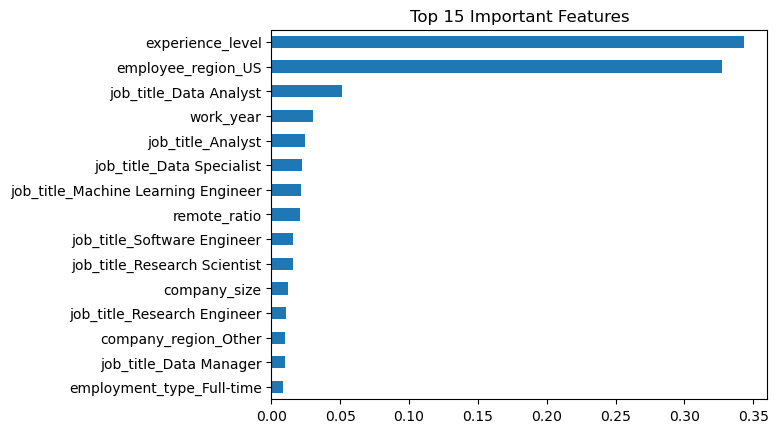

In [17]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

# Plot top 15
feat_importance.head(15).plot(kind='barh')
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()

**Note**: XGBoost needs to be installed separately using pip install xgboost

In [19]:
from xgboost import XGBRegressor

In [20]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_results = evaluate_model(
    xgb, X_train, X_test, y_train, y_test, "XGBoost (Base)"
)

📌 XGBoost (Base)
RMSE: 0.4241
MAE : 0.3351
R²  : 0.3400


In [21]:
results = pd.concat([
    results,
    pd.DataFrame([xgb_results])
], ignore_index=True)

results.sort_values(by="RMSE")

,Model,RMSE,MAE,R2
6,XGBoost (Base),0.424074,0.335065,0.339982
5,Random Forest,0.425328,0.335595,0.336074
2,Ridge Regression,0.429117,0.338386,0.324193
1,Linear Regression,0.429123,0.338388,0.324173
4,Decision Tree,0.431092,0.340023,0.317957
3,Lasso Regression,0.449417,0.356020,0.258738
0,Baseline,0.521992,0.411511,-0.000001


## Model Comparison Insights

- XGBoost achieved the best performance, followed closely by Random Forest  
- Tree-based models outperform linear models, indicating non-linear relationships  
- Lasso performed worse due to aggressive feature selection  
- Significant improvement over baseline confirms model effectiveness  

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -cv_scores

print("Cross-Validation RMSE Scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())

Cross-Validation RMSE Scores: [0.41323622 0.43262839 0.44651638 0.42550448 0.42758751]
Mean RMSE: 0.42909459731210564


In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [24]:
xgb_model = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 6, 8, 10],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_root_mean_squared_error', verbose=1)

In [25]:
best_xgb = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [26]:
xgb_tuned_results = evaluate_model(
    best_xgb, X_train, X_test, y_train, y_test, "XGBoost (Tuned)"
)

📌 XGBoost (Tuned)
RMSE: 0.4238
MAE : 0.3348
R²  : 0.3407


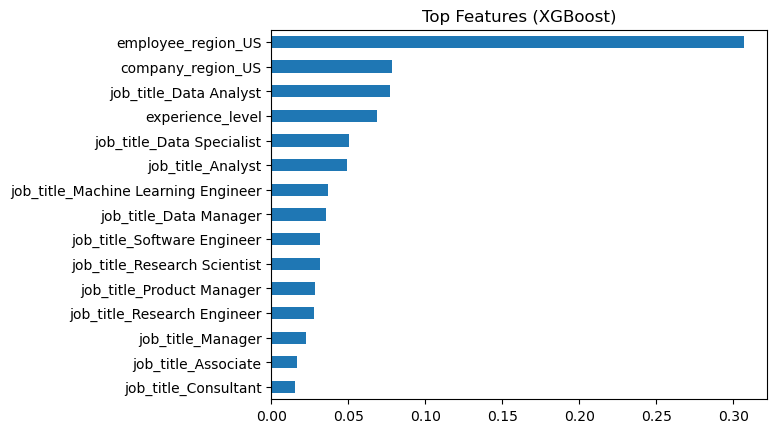

In [27]:
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
features = X.columns

feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

feat_importance.head(15).plot(kind="barh")
plt.title("Top Features (XGBoost)")
plt.gca().invert_yaxis()
plt.show()